1. Import and Tickers

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# All four tickers that we need
TICKERS = {
    "usd_inr": "INRUSD=X",
    "usd_cny": "CNYUSD=X",
    "soybean_futures": "ZS=F",
    "brent_crude": "BZ=F",
}

print("Ticker ready:", TICKERS)
print("yfinance version:", yf.__version__)

Ticker ready: {'usd_inr': 'INRUSD=X', 'usd_cny': 'CNYUSD=X', 'soybean_futures': 'ZS=F', 'brent_crude': 'BZ=F'}
yfinance version: 1.3.0


2. Pull all four tickers 

In [2]:
df_raw = yf.download(
    tickers=list(TICKERS.values()),
    start="2015-01-01",
    auto_adjust=True, # adjust for dividends/splits
    progress=False, # suppress progress bar for cleaner output
)

print("Shape:", df_raw.shape)
print("Columns:", df_raw.columns.to_list())
print("Index type:", type(df_raw.index))
print("Index sample:", df_raw.index[:3].to_list())
df_raw.head(3)

Shape: (2965, 20)
Columns: [('Close', 'BZ=F'), ('Close', 'CNYUSD=X'), ('Close', 'INRUSD=X'), ('Close', 'ZS=F'), ('High', 'BZ=F'), ('High', 'CNYUSD=X'), ('High', 'INRUSD=X'), ('High', 'ZS=F'), ('Low', 'BZ=F'), ('Low', 'CNYUSD=X'), ('Low', 'INRUSD=X'), ('Low', 'ZS=F'), ('Open', 'BZ=F'), ('Open', 'CNYUSD=X'), ('Open', 'INRUSD=X'), ('Open', 'ZS=F'), ('Volume', 'BZ=F'), ('Volume', 'CNYUSD=X'), ('Volume', 'INRUSD=X'), ('Volume', 'ZS=F')]
Index type: <class 'pandas.DatetimeIndex'>
Index sample: [Timestamp('2015-01-01 00:00:00'), Timestamp('2015-01-02 00:00:00'), Timestamp('2015-01-05 00:00:00')]


Price           Close                                    High            \
Ticker           BZ=F  CNYUSD=X  INRUSD=X     ZS=F       BZ=F  CNYUSD=X   
Date                                                                      
2015-01-01        NaN  0.161392  0.015866      NaN        NaN  0.161392   
2015-01-02  56.419998  0.161392  0.015866  1002.50  58.220001  0.161392   
2015-01-05  53.110001  0.161392  0.015803  1039.75  56.290001  0.161392   

Price                                Low                               \
Ticker      INRUSD=X     ZS=F       BZ=F  CNYUSD=X  INRUSD=X     ZS=F   
Date                                                                    
2015-01-01  0.015866      NaN        NaN  0.161392  0.015850      NaN   
2015-01-02  0.015898  1017.75  55.520000  0.161392  0.015758  1002.25   
2015-01-05  0.015830  1041.25  52.669998  0.161057  0.015753  1001.50   

Price            Open                                Volume                    \
Ticker           BZ=F  CNYUSD=X  INRUSD=X     ZS=F     BZ=F CNYUSD=X INRUSD=X   
Date                                                                            
2015-01-01        NaN  0.161392  0.015866      NaN      NaN      0.0      0.0   
2015-01-02  57.630001  0.161392  0.015850  1017.75  16707.0      0.0      0.0   
2015-01-05  56.290001  0.161392  0.015803  1002.50  30065.0      0.0      0.0   

Price               
Ticker        ZS=F  
Date                
2015-01-01     NaN  
2015-01-02  9173.0  
2015-01-05  7451.0

3. Extract only Close prices, flatten the MultiIndex

In [3]:
df_close = df_raw["Close"].copy()

print("Columns after extracting Close:", df_close.columns.to_list())
print("Shape:", df_close.shape)
df_close.head(5)


Columns after extracting Close: ['BZ=F', 'CNYUSD=X', 'INRUSD=X', 'ZS=F']
Shape: (2965, 4)


Ticker,BZ=F,CNYUSD=X,INRUSD=X,ZS=F
Date,,,,
2015-01-01,NaN,0.161392,0.015866,NaN
2015-01-02,56.419998,0.161392,0.015866,1002.50
2015-01-05,53.110001,0.161392,0.015803,1039.75
2015-01-06,51.099998,0.161072,0.015788,1051.00
2015-01-07,51.150002,0.161238,0.015731,1052.75


4. Rename to meaningful names

In [4]:
df_close = df_close.rename(columns={
    "INRUSD=X": "inr_per_usd_raw",
    "CNYUSD=X": "cny_per_usd_raw",
    "ZS=F": "soybean_futures_usd",
    "BZ=F": "brent_crude_usd",
})

print(df_close.columns.to_list())
df_close.head(5)

['brent_crude_usd', 'cny_per_usd_raw', 'inr_per_usd_raw', 'soybean_futures_usd']


Ticker,brent_crude_usd,cny_per_usd_raw,inr_per_usd_raw,soybean_futures_usd
Date,,,,
2015-01-01,NaN,0.161392,0.015866,NaN
2015-01-02,56.419998,0.161392,0.015866,1002.50
2015-01-05,53.110001,0.161392,0.015803,1039.75
2015-01-06,51.099998,0.161072,0.015788,1051.00
2015-01-07,51.150002,0.161238,0.015731,1052.75


5. Flip FX direction and check null counts

In [5]:
# Flip: we want how many INR/CNY per 1 USD (rising = weakening local currency)
df_close["usd_inr"] = 1/df_close["inr_per_usd_raw"]
df_close["usd_cny"] = 1/df_close["cny_per_usd_raw"]

# Drop the raw columns we no longer need
df_close = df_close.drop(columns=["inr_per_usd_raw", "cny_per_usd_raw"])



In [6]:
print("Null counts:\n", df_close.isnull().sum())
print("\nSamples values (USD/INR should be ~63 in 2015, ~95 in 2026):")
print(df_close["usd_inr"].iloc[[0, -2]])

Null counts:
 Ticker
brent_crude_usd        104
soybean_futures_usd    106
usd_inr                  5
usd_cny                  6
dtype: int64

Samples values (USD/INR should be ~63 in 2015, ~95 in 2026):
Date
2015-01-01    63.027998
2026-05-17          NaN
Name: usd_inr, dtype: float64


6. Resample daily to monthly

In [7]:
# Use month-end mean — more stable than last trading day for FX
# For futures, last trading day of month is more standard
df_monthly = df_close.resample("MS").agg({   # MS = month start
    "usd_inr":              "mean",
    "usd_cny":              "mean",
    "soybean_futures_usd":  "last",   # last trading day of month
    "brent_crude_usd":      "last"
})

# Rename index
df_monthly.index.name = "month_date"
df_monthly = df_monthly.reset_index()

print("Shape:", df_monthly.shape)
print("Date range:", df_monthly["month_date"].min(), "→", df_monthly["month_date"].max())
print("\nNull counts:\n", df_monthly.isnull().sum())
df_monthly.head(3)

Shape: (137, 5)
Date range: 2015-01-01 00:00:00 → 2026-05-01 00:00:00

Null counts:
 Ticker
month_date             0
usd_inr                0
usd_cny                0
soybean_futures_usd    0
brent_crude_usd        0
dtype: int64


Ticker,month_date,usd_inr,usd_cny,soybean_futures_usd,brent_crude_usd
0,2015-01-01,62.203273,6.205977,961.00,52.990002
1,2015-02-01,62.033851,6.241065,1030.75,62.580002
2,2015-03-01,62.459910,6.232450,973.25,55.110001


7. Quick plot

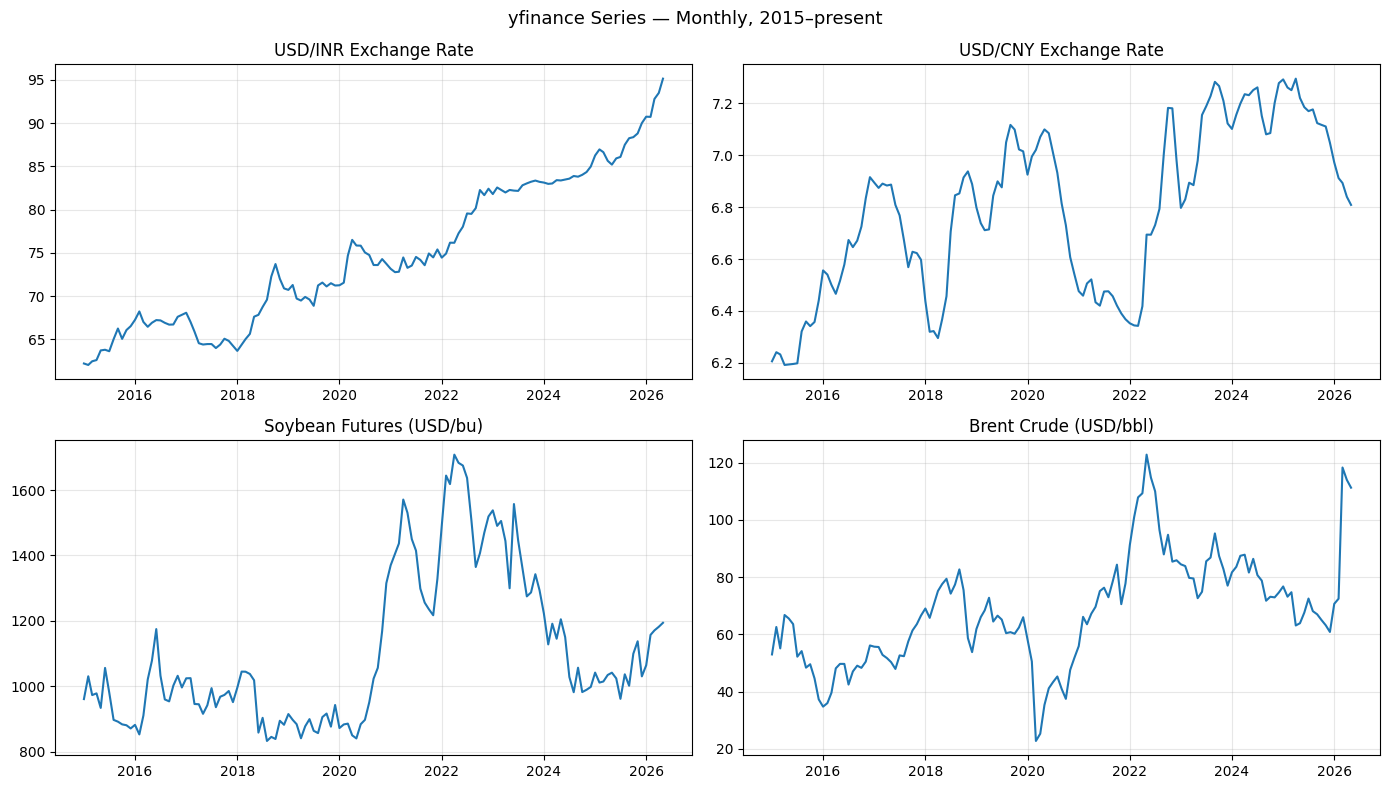

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plots = [
    ("usd_inr",             "USD/INR Exchange Rate",      axes[0,0]),
    ("usd_cny",             "USD/CNY Exchange Rate",      axes[0,1]),
    ("soybean_futures_usd", "Soybean Futures (USD/bu)",   axes[1,0]),
    ("brent_crude_usd",     "Brent Crude (USD/bbl)",      axes[1,1]),
]

for col, title, ax in plots:
    ax.plot(df_monthly["month_date"], df_monthly[col])
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.suptitle("yfinance Series — Monthly, 2015–present", fontsize=13)
plt.tight_layout()
plt.show()

## Notebook 02 — Findings & Decisions

**Source:** yfinance 1.3.0 \
**Tickers confirmed:** INRUSD=X, CNYUSD=X, ZS=F, BZ=F \
**Date range:** 2015-01-01 → 2026-05-01 \
**Shape:** 137 rows × 5 columns (after monthly resample) \
**Null values:** None

**Columns for pipeline:**
- month_date (datetime, first of month)
- usd_inr (monthly mean, INR per 1 USD)
- usd_cny (monthly mean, CNY per 1 USD)
- soybean_futures_usd (month-end last, USD/bushel)
- brent_crude_usd (month-end last, USD/barrel)

**FX direction:** Pulled as INRUSD=X and CNYUSD=X (USD per foreign unit),
flipped to USD per local currency so rising = weakening local currency.

**Resampling decisions:**
- FX rates → monthly mean (smooth daily noise)
- Futures → monthly last (standard market convention, month-end settlement)

**Key observations:**
- INR weakened ~48% vs USD from 2015–2026 (64 → 95)
- CNY more range-bound (6.2–7.4), reflects managed float policy
- Soybean futures confirm 2022 spike seen in World Bank data ✓
- Brent crude COVID crash (2020) and war spike (2022) clearly visible
- Recent Brent spike (~$115, 2026) = stronger biodiesel demand signal for CPO